## “Fortune 500 Company Segmentation Using K-Means Clustering”

* Question 1 Can Fortune 500 companies be grouped into distinct business segments based on revenue, employee count, and industry characteristics?
* Question 2 Which industries dominate the Fortune 500 in terms of revenue, workforce size, and profitability?

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
fortune=pd.read_csv("fortune500.csv")
fortune

,rank,company,industry,revenue,city,state,zip,website,employees,ceo
0,1,Amazon,Internet Services and Retailing,"7,16,92,40,00,000",Seattle,Washington,98109,amazon.com,"15,56,000",Andrew Jassy
1,2,Walmart,General Merchandisers,"7,12,70,00,00,000",Bentonville,Arkansas,72716,walmart.com,"21,00,000",John Furner
2,3,UnitedHealth,Health Care: Insurance and Managed Care,"4,47,60,00,00,000",Eden Prairie,Minnesota,55344,unitedhealthgroup.com,"4,00,000",Stephen Hemsley
3,4,Apple,"Computers, Office Equipment","4,16,16,10,00,000",Cupertino,California,95014,apple.com,"1,64,000",Timothy Cook
4,5,Alphabet,Internet Services and Retailing,"4,02,83,60,00,000",Mountain View,California,94043,abc.xyz,"1,83,323",Sundar Pichai
...,...,...,...,...,...,...,...,...,...,...
495,496,Electronic Arts,Entertainment,"7,29,00,00,000",Redwood City,California,94065,ea.com,"13,700",Andrew Wilson
496,497,Newell Brands,"Home Equipment, Furnishings","7,26,00,00,000",Atlanta,Georgia,30328,newellbrands.com,"23,700",Christopher Peterson
497,498,Ingredion,Food Production,"7,26,00,00,000",Westchester,Illinois,60154,ingredion.com,"11,200",James Zallie
498,499,KeyCorp,Commercial Banks,"7,20,00,00,000",Cleveland,Ohio,44114,key.com,"16,753",Christopher Gorman


In [4]:
fortune.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   rank       500 non-null    int64 
 1   company    500 non-null    object
 2   industry   500 non-null    object
 3   revenue    500 non-null    object
 4    city      500 non-null    object
 5   state      500 non-null    object
 6   zip        500 non-null    int64 
 7   website    500 non-null    object
 8   employees  500 non-null    object
 9   ceo        500 non-null    object
dtypes: int64(2), object(8)
memory usage: 39.2+ KB


In [5]:
fortune.describe()

,rank,zip
count,500.000000,500.000000
mean,250.500000,47829.520000
std,144.481833,30638.259507
min,1.000000,1104.000000
25%,125.750000,20004.500000
50%,250.500000,46236.000000
75%,375.250000,77002.000000
max,500.000000,98390.000000


In [7]:
fortune['revenue'] = fortune['revenue'].replace('[\\$,]', '', regex=True).astype(float)

fortune['employees'] = fortune['employees'].replace('[\\,]', '', regex=True).astype(float)

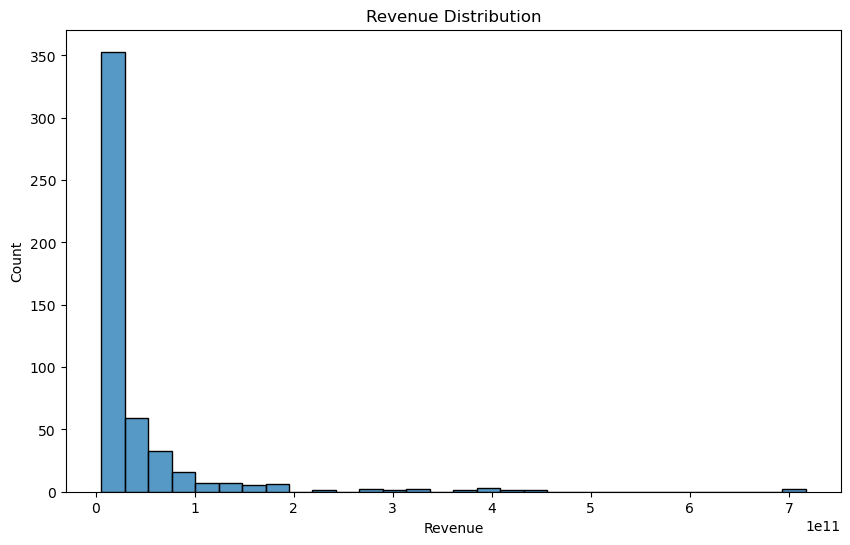

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(fortune['revenue'], bins=30)

plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.show()

## Average employees by industry

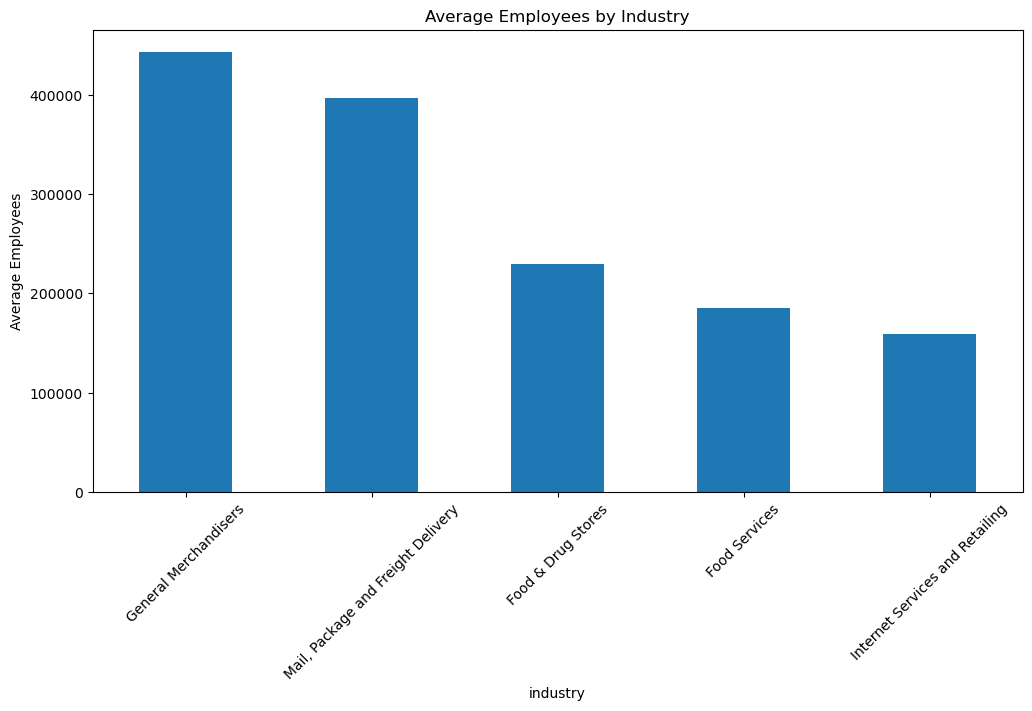

In [14]:
industry_emp = fortune.groupby('industry')['employees'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(12,6))

industry_emp.plot(kind='bar')

plt.title('Average Employees by Industry')
plt.ylabel('Average Employees')

plt.xticks(rotation=45)
plt.show()

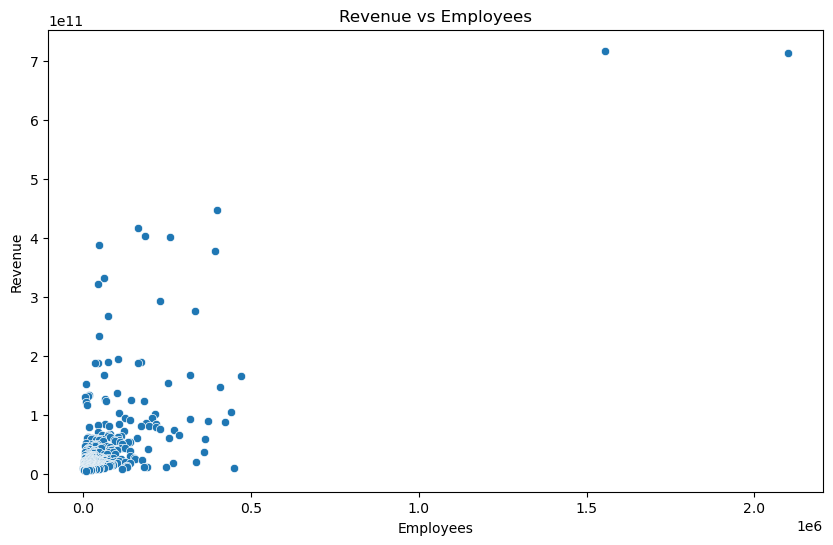

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='employees',
    y='revenue',
    data=fortune
)

plt.title('Revenue vs Employees')
plt.xlabel('Employees')
plt.ylabel('Revenue')

plt.show()

## Revenue per employee

In [15]:
fortune['Revenue_per_Employee'] = (fortune['revenue'] / fortune['employees'])

In [16]:
fortune

,rank,company,industry,revenue,city,state,zip,website,employees,ceo,Revenue_per_Employee
0,1,Amazon,Internet Services and Retailing,7.169240e+11,Seattle,Washington,98109,amazon.com,1556000.0,Andrew Jassy,4.607481e+05
1,2,Walmart,General Merchandisers,7.127000e+11,Bentonville,Arkansas,72716,walmart.com,2100000.0,John Furner,3.393810e+05
2,3,UnitedHealth,Health Care: Insurance and Managed Care,4.476000e+11,Eden Prairie,Minnesota,55344,unitedhealthgroup.com,400000.0,Stephen Hemsley,1.119000e+06
3,4,Apple,"Computers, Office Equipment",4.161610e+11,Cupertino,California,95014,apple.com,164000.0,Timothy Cook,2.537567e+06
4,5,Alphabet,Internet Services and Retailing,4.028360e+11,Mountain View,California,94043,abc.xyz,183323.0,Sundar Pichai,2.197411e+06
...,...,...,...,...,...,...,...,...,...,...,...
495,496,Electronic Arts,Entertainment,7.290000e+09,Redwood City,California,94065,ea.com,13700.0,Andrew Wilson,5.321168e+05
496,497,Newell Brands,"Home Equipment, Furnishings",7.260000e+09,Atlanta,Georgia,30328,newellbrands.com,23700.0,Christopher Peterson,3.063291e+05
497,498,Ingredion,Food Production,7.260000e+09,Westchester,Illinois,60154,ingredion.com,11200.0,James Zallie,6.482143e+05
498,499,KeyCorp,Commercial Banks,7.200000e+09,Cleveland,Ohio,44114,key.com,16753.0,Christopher Gorman,4.297738e+05


## Clustering features

In [17]:
features = fortune[[
    'revenue',
    'employees',
    'Revenue_per_Employee'
]]

In [18]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Finding optimal clusters

C:\Users\joshu\OneDrive\Desktop\sample_project_1\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\joshu\OneDrive\Desktop\sample_project_1\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\joshu\OneDrive\Desktop\sample_project_1\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\joshu\OneDrive\Desktop\sample_project_1\env

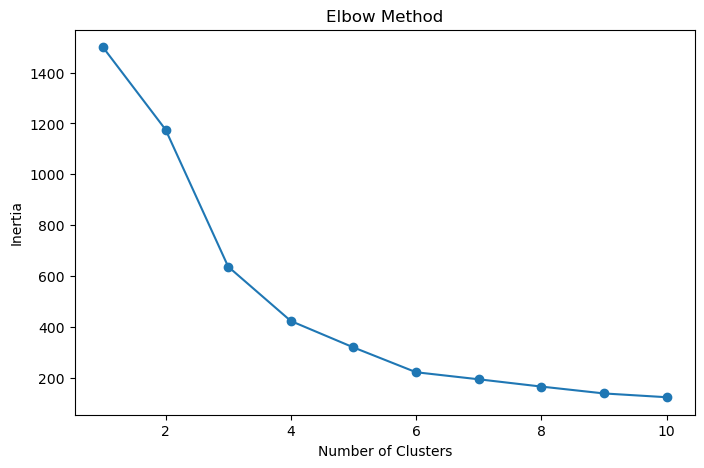

In [19]:
inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

## K Means Clustering 

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42)

fortune['Cluster'] = kmeans.fit_predict(scaled_features)

C:\Users\joshu\OneDrive\Desktop\sample_project_1\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [21]:
score = silhouette_score(scaled_features, fortune['Cluster'])

print('Silhouette Score:', score)

Silhouette Score: 0.7324218253055339


## PCA analysis

In [22]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

fortune['PCA1'] = pca_features[:,0]
fortune['PCA2'] = pca_features[:,1]

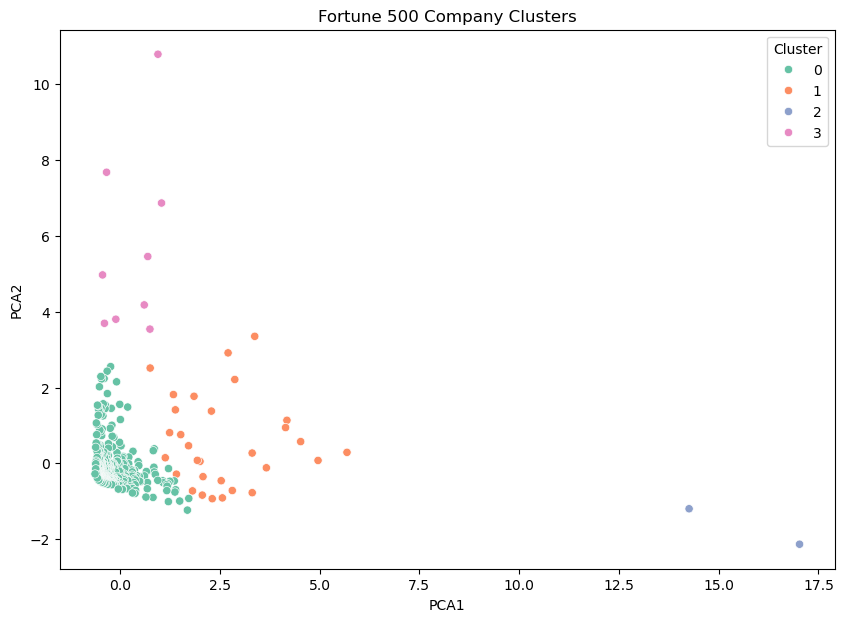

In [28]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=fortune,
    palette='Set2'
)

plt.title('Fortune 500 Company Clusters')

plt.show()

In [29]:
pd.options.display.float_format = '{:,.2f}'.format

In [30]:
fortune.groupby('Cluster')[[
    'revenue',
    'employees',
    'Revenue_per_Employee'
]].mean()

,revenue,employees,Revenue_per_Employee
Cluster,,,
0,"24,207,708,061.00","45,622.07","1,092,191.86"
1,"228,930,166,666.67","206,282.97","2,362,420.38"
2,"714,812,000,000.00","1,828,000.00","400,064.51"
3,"82,265,777,777.78","5,665.00","15,871,634.47"


* Key Findings
Cluster 0 — Traditional Large Enterprises
Companies in this cluster generate moderate revenue with medium-sized workforces and balanced operational efficiency.
These organizations likely represent traditional industrial, healthcare, and manufacturing firms that maintain stable large-scale operations.

* Cluster 1 — High-Performance Enterprise Leaders
This cluster contains corporations with extremely high revenue and large employee bases while maintaining strong revenue efficiency per employee.
These companies demonstrate the ability to scale successfully while remaining operationally productive, making them dominant enterprise leaders.

* Cluster 2 — Workforce-Driven Mega Corporations
Companies in this segment generate the highest total revenue but rely on extremely large workforces.
Despite massive revenue generation, these organizations show lower revenue per employee, suggesting labor-intensive operational models commonly seen in large retail, logistics, and distribution enterprises.
This highlights that larger workforce scale does not always translate into higher operational efficiency.

* Cluster 3 — Ultra Efficient Corporations
This cluster is the most operationally efficient segment discovered by the model.
These companies generate very high revenue while maintaining relatively small employee counts, resulting in exceptionally high revenue per employee.


* This suggests highly scalable business models driven by:
Technology
Automation
Intellectual property
Financial services
Software-based operations
These organizations demonstrate how modern enterprises can maximize revenue generation without depending on massive workforce expansion.